In [40]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm

In [41]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In this notebook we use a diffusion model to generate circle data.  First we define the noise schedule $\beta_t$ and the corresponding $\alpha_t = 1 - \beta_t$ and $\bar\alpha_t = \Pi_{s=1}^t \alpha_s$.  Following [this paper](https://arxiv.org/abs/2102.09672), we define
$$\bar\alpha_t = \frac{f(t)}{f(0)}, \text{ with } f(t) = \cos\left(\frac{t/T + s}{1 + s}\cdot\frac{\pi}{2}\right),$$
where we take $s = 0.008, T = 100$ and also
$$\beta_t  = 1 - \frac{\bar\alpha_t}{\bar\alpha_{t-1}},$$
in addition to clipping the maximum value of $\beta_t$ to be 0.999.

In [333]:
s = 0.008
T = 100
t = torch.linspace(0, T, 101)
f = torch.cos(((t/T + s) / (1 + s)) * torch.pi / 2) ** 2
a_bar = f / f[0]
beta = torch.clamp(1 - a_bar[1:] / a_bar[:-1], max=0.999)
alpha = 1 - beta
alpha_bar = a_bar[1:]

Recall that the reverse diffusion process using a noise neural network $\epsilon_\theta$ is given as follows:
$$\mu_\theta(x_t,t) = \frac{1}{\sqrt{\alpha_t}}\left(x_t - \frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\epsilon_\theta(x_t,t)\right)$$
$$q_\theta(x_{t-1}| x_t) = \mathcal N\left(\mu_\theta(x_t,t), \frac{1-\bar\alpha_t}{1-\bar\alpha_{t-1}}\beta_t I\right).$$
We see that if $\alpha_t$ is too close to zero near $t=T$, the reverse diffusion process can become unstable as the mean $\mu_theta$ blows up.  Clipping $\beta_t$ to 0.999 forces $\alpha_t$ to be at least 0.001 preventing the blow up.

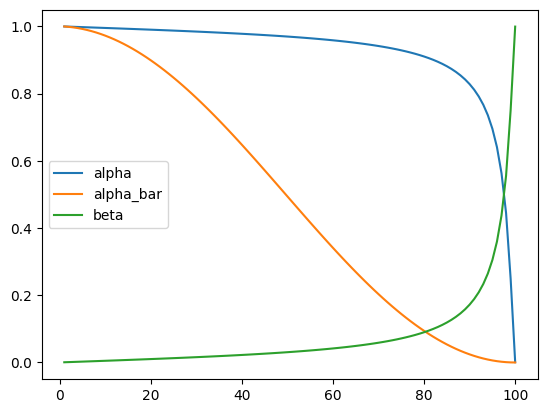

In [334]:
plt.plot(t[1:], alpha, label="alpha")
plt.plot(t[1:], alpha_bar, label="alpha_bar")
plt.plot(t[1:], beta, label="beta")
plt.legend()
plt.show()

We define a `Diffuser` class that implements the forward and reverse diffusion process given $\alpha_t$, $\bar\alpha_t$ and $\beta_t$.  Since the forward diffusion process is given by
$$q(x_t|x_0) = \mathcal N(\sqrt{\bar\alpha_t}x_0, (1-\bar\alpha_t) I),$$
we can sample all $x_t$ at once without doing it consecutively.

In [335]:
class Diffuser:
    def __init__(self, alpha, alpha_bar, beta):
        self.alpha = alpha
        self.alpha_bar = alpha_bar
        self.beta = beta

    def __call__(self, x, t=None, model=None, order="forward", with_normal=False):
        if order == "forward":
            num_dim = len(x.size())
            num_t = len(self.alpha_bar)
            eps = torch.randn_like(x.expand((num_t, ) + (-1, ) * num_dim))
            x_t = torch.sqrt(self.alpha_bar[(..., ) + (None, ) * num_dim]) * x + torch.sqrt(1 - self.alpha_bar[(..., ) + (None, ) * num_dim]) * eps

            if with_normal:
                return torch.cat((torch.unsqueeze(x, 0), x_t)), torch.cat((torch.zeros(x.size())[None, ...], eps))
            else:
                return torch.cat((torch.unsqueeze(x, 0), x_t))
            
        if order == "reverse":
            assert model is not None
            assert t is not None
            
            model.eval()

            with torch.no_grad():
                time = torch.tensor([t], device=device)
                mu = (x - self.beta[t - 1] * model(x, time) / torch.sqrt(1 - self.alpha_bar[t - 1])) / torch.sqrt(self.alpha[t - 1])

                if t > 1:
                    return mu + torch.sqrt((1 - self.alpha_bar[t - 2]) * self.beta[t - 1] / (1 - self.alpha_bar[t - 1])) * torch.randn_like(x)
                if t == 1:
                    return mu


In [336]:
diffuser = Diffuser(alpha, alpha_bar, beta)

We define a simple MLP with a time embedding given in the implementation of the [DDPM paper](https://arxiv.org/abs/2006.11239).  This MLP is used to model the noise.

In [337]:
class TimeEmbedding(nn.Module):
    def __init__(self, hidden_dim, half_embed_dim=16):
        super().__init__()
        self.half_embed_dim = half_embed_dim
        self.fc = nn.Linear(half_embed_dim * 2, hidden_dim)

    def forward(self, t):
        freq = 10000 ** (-1 * (torch.arange(0, self.half_embed_dim) / (self.half_embed_dim - 1)))
        t_embed = t[:, None] * freq
        return self.fc(torch.cat((torch.sin(t_embed), torch.cos(t_embed)), dim=-1))

class MLP(nn.Module):
    def __init__(self, embed_dim=32, hidden_dim=512):
        super().__init__()
        self.activation = nn.LeakyReLU()
        self.embedding = TimeEmbedding(hidden_dim, half_embed_dim=int(embed_dim / 2))
        self.fc1 = nn.Linear(2, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, 2)

    def forward(self, x, t):
        t_embed = self.embedding(t)
        x = self.fc1(x)
        x += t_embed
        x = self.activation(x)
        x = self.activation(self.fc2(x) + t_embed)
        x = self.activation(self.fc3(x) + t_embed)
        x = self.fc4(x)
        return x
        

We generate the circle dataset by sampling iid standard normal random variables $(X, Y)$, normalizing them and multiply them with a factor of $1.5$.  This gives us a uniform distribution on the circle $x^2 + y^2 = 1.5^2$.

In [338]:
normal = torch.randn(100, 2)
circle_dataset = 1.5 * normal / torch.norm(normal, dim=-1)[:, None]

We now plot how the dataset undergoes the forward difussion process.

In [339]:
circle_t = diffuser(circle_dataset)

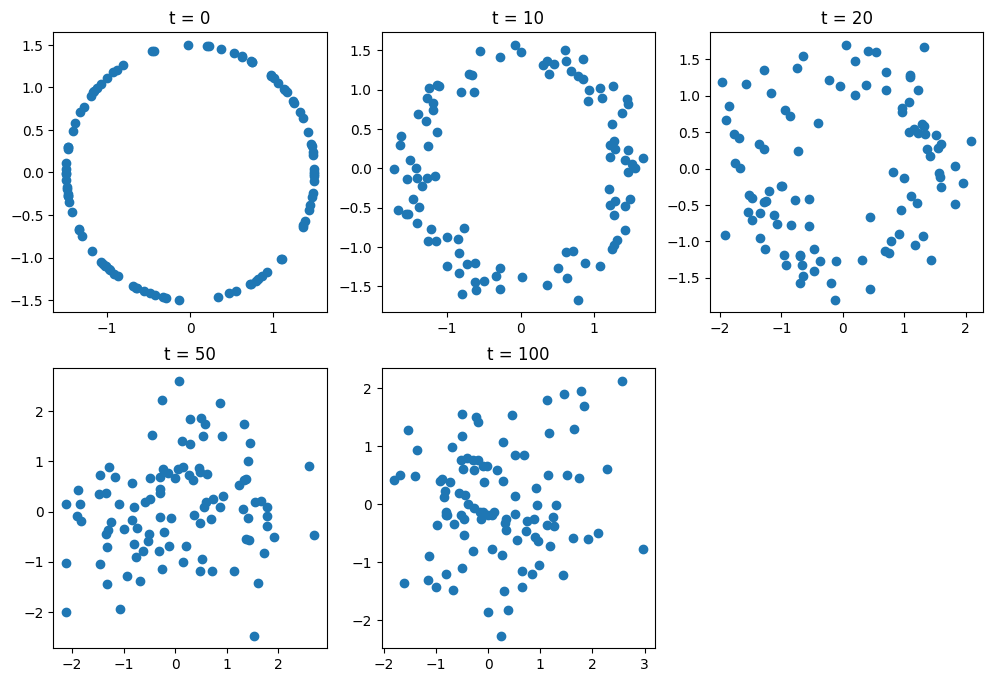

In [340]:
fig = plt.figure(figsize=(12, 8))
ax1 = fig.add_subplot(2,3,1)
ax2 = fig.add_subplot(2,3,2)
ax3 = fig.add_subplot(2,3,3)
ax4 = fig.add_subplot(2,3,4)
ax5 = fig.add_subplot(2,3,5)
ax1.scatter(circle_t[0][:, 0], circle_t[0][:, 1])
ax1.set_title("t = 0")
ax2.scatter(circle_t[10][:, 0], circle_t[10][:, 1])
ax2.set_title("t = 10")
ax3.scatter(circle_t[20][:, 0], circle_t[20][:, 1])
ax3.set_title("t = 20")
ax4.scatter(circle_t[50][:, 0], circle_t[50][:, 1])
ax4.set_title("t = 50")
ax5.scatter(circle_t[100][:, 0], circle_t[100][:, 1])
ax5.set_title("t = 100")
plt.show()

We now train our neural network using the simplified objective in the [DDPM paper](https://arxiv.org/abs/2006.11239):
$$\mathcal L_{\text{simple}} = \mathbb E\|\epsilon - \epsilon_\theta(\sqrt{\bar\alpha_t}x_0 + \sqrt{1-\bar\alpha_t}\epsilon, t)\|^2.$$

In [341]:
batch_size = 25
circle_dataloader = DataLoader(circle_dataset, batch_size=batch_size, shuffle=True)
noise_model = MLP()

In [342]:
def train(model, train_loader, num_epoch):

    model = model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    tqdm_epoch = tqdm(range(num_epoch))
    avg_loss = []

    for epoch in tqdm_epoch:

        model.train()

        total_loss = 0
        total_num = 0

        for data in train_loader:

            data = data.to(device)

            optimizer.zero_grad()
            
            t = torch.randint(low=1, high=T + 1, size=(data.size(0), ))
            data_t, eps = diffuser(data, with_normal=True)
            loss = torch.mean(torch.sum((torch.diagonal(eps[t]).t() - model(torch.diagonal(data_t[t]).t(), t)) ** 2, dim=-1))
            loss.backward()

            optimizer.step()

            total_loss += loss.detach().item() * data.size(0)
            total_num += data.size(0)

        avg_loss.append(total_loss / total_num)
        tqdm_epoch.set_description(f'Average loss: {total_loss / total_num}')

    print("Training complete")


In [343]:
train(noise_model, circle_dataloader, 1000)

Average loss: 0.8784317672252655: 100%|████| 1000/1000 [00:09<00:00, 111.01it/s]

Training complete


We now sample in two ways using the reverse diffusion process and our neural network.  One way is the standard sampling given in the [DDPM paper](https://arxiv.org/abs/2006.11239), the other way is physics-based sampling.  The physics based sampling uses the training method in [this paper](https://arxiv.org/abs/2403.14404) in inference time just like the corrected sampling method used in [this paper](https://arxiv.org/abs/2312.10527).  We follow just like in standard sampling a reverse diffusion step, and after this we estimate $\mathbb E[x_0|x_t]$ by
$$\hat x_0 = \frac{1}{\sqrt{\bar\alpha_t}}(x_t - \sqrt{1-\bar\alpha_t}\epsilon_\theta(x_t,t)).$$
Then we evaluate our physical loss on $\hat x_0$ and perform a gradient descent step on $x_t$.  Here our physical loss is given by
$$\mathcal L_{\text{physical}} = |\sqrt{x^2 + y^2} - 1.5|.$$
We plot our samples and calculate the average physical loss for both samples and we see the physics-based samples adhere closer to the physical constraint.

In [363]:
def physics_loss(x):
    return torch.mean(torch.abs(torch.norm(x, dim=-1) - 1.5))

def sampling(model):
    x = torch.randn(100, 2, requires_grad=True, device=device)
    t = T
    for params in model.parameters():
        params.require_grad = False
    
    while t >= 1:
        x = diffuser(x, t=t, model=model, order='reverse')

        y = x.detach().requires_grad_()
        loss = physics_loss((y - (torch.sqrt(1 - alpha_bar[t - 1])
                                  * model(y, torch.tensor([t], requires_grad=False, device=device))))
                            / torch.sqrt(alpha_bar[t - 1]))
        loss.backward()
        y = y - y.grad
        y.grad = None
        
        t -= 1
    fig = plt.figure(figsize=(12,6))
    ax1 = fig.add_subplot(1,2,1)
    ax2 = fig.add_subplot(1,2,2)
    ax1.scatter(x[:, 0].detach().cpu(), x[:, 1].detach().cpu())
    ax1.set_title("diffusion sampling")
    ax2.scatter(y[:, 0].detach().cpu(), y[:, 1].detach().cpu())
    ax2.set_title("physics-based diffusion sampling")
    plt.show()
    print((f'Average physical loss without correction: {physics_loss(x)}\n'
    f'Average physical loss with physics-based sampling: {physics_loss(y)}'))


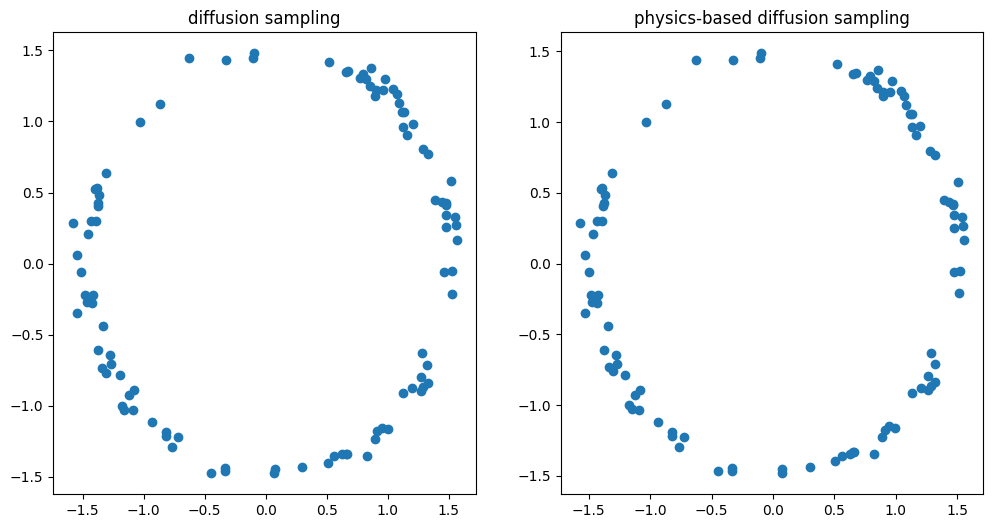

Average physical loss without correction: 0.04395003244280815
Average physical loss with physics-based sampling: 0.0377214178442955


In [364]:
sampling(noise_model)